# 07 — StyleGAN Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what makes **StyleGAN** different from the simple GAN of example 05: a **mapping network**, per-layer **style injection**, and the **truncation trick**
- Build a mapping network and inspect how it reshapes the latent distribution
- Implement the **truncation trick** on a trained GAN and measure its diversity-vs-typicality trade-off

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lessons 05-06 (the GAN and its conditioning) — StyleGAN keeps the adversarial loop and rebuilds only how the latent code enters the generator.

**Used later in:** Course 10 — Unit 3, lesson 05 and Unit 5, lesson 04, which place StyleGAN against diffusion systems.

---

## Introduction

**StyleGAN** (Karras et al., 2019) generates some of the most realistic synthetic faces ever made. Three architectural ideas separate it from our simple GAN:

1. **Mapping network**: instead of feeding the Gaussian noise z straight into the generator, an 8-layer MLP first maps z → w. The *w-space* is free to take any shape, which lets the model organize it by visual attributes (pose, age, lighting) far better than the rigid Gaussian z-space.
2. **Style injection (AdaIN)**: w does not enter the generator once at the bottom — a learned transform of w rescales the feature maps at *every* layer. Coarse layers control pose/shape, fine layers control texture/color; mixing different w's at different layers ("style mixing") mixes those attributes.
3. **Truncation trick**: at sampling time, pull latents toward the average — trading diversity for typicality/quality.

A full StyleGAN needs days of GPU training, so this notebook does two honest small-scale experiments: (1) build a mapping network and watch it reshape the latent distribution; (2) apply the truncation trick to the example-05 GAN and *measure* the trade-off.

---

## 🌍 Why this lesson exists — "Katie Jones", LinkedIn, June 2019

In June 2019 the Associated Press reported a LinkedIn profile named Katie Jones: a think-tank job that did not exist, a degree that did not exist, and connections to a deputy assistant secretary of state and a senior Senate aide. Experts who examined the profile photograph concluded it was almost certainly produced by a **generative adversarial network**; the giveaway was a melted-looking earring. StyleGAN-quality faces of people who do not exist went from a research paper to a documented espionage technique in months.

**What goes wrong without this:** if you cannot explain *why* these faces are convincing — a latent space reorganised so that plausible faces are dense and typical ones densest — you cannot reason about the truncation knob that deletes the weird outputs, and you will read "this looks real" as "this is real". The artefact that exposed Katie Jones lives in exactly the tail that truncation removes.


## Part 1 — The Mapping Network: z → w

We build a small mapping MLP and pass 5,000 Gaussian samples through it.

**The point to see:** z-space is a perfectly round, featureless ball — every direction in it is statistically identical, so no direction can *mean* anything. Running z through an MLP destroys that symmetry: even with untrained weights the resulting w-cloud is squashed, off-centre, and concentrated on far fewer directions than it has dimensions. That freedom is the precondition for a trained StyleGAN organising w by pose, age and lighting. Below we measure the difference rather than assert it. (No adversarial training is needed for this architecture walkthrough — and the "Where this breaks" note at the end says exactly what an *untrained* mapping network does and does not prove.)

z shape: (5000, 32)  →  w shape: (5000, 32)
z dim 0: mean +0.021  std 0.997   (Gaussian by construction)
w dim 0: mean +0.115  std 0.071   (whatever the MLP makes it)


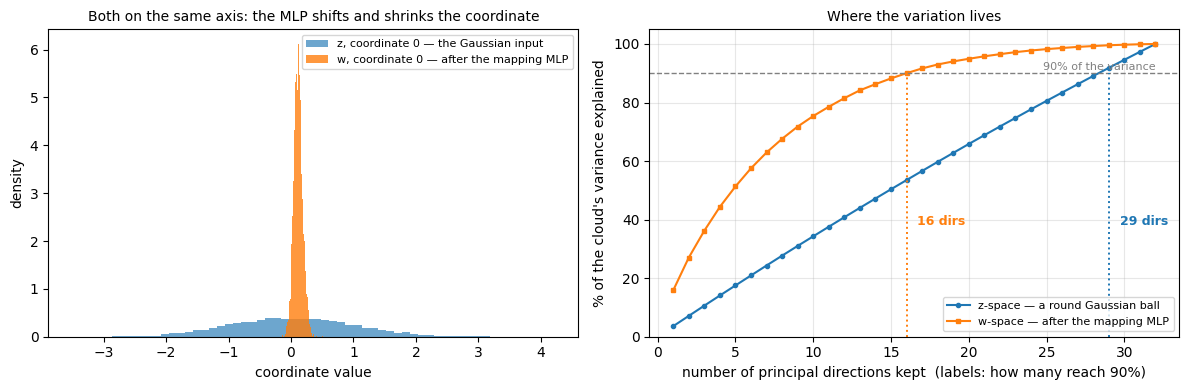


Strongest single direction:  z 3.6% of variance   |   w 15.9%
Directions needed for 90%:   z 29 of 32          |   w 16 of 32
Mean |correlation| between different coordinates: z 0.012   w 0.160

In StyleGAN, a learned transform of w then RESCALES the feature maps at
every generator layer (AdaIN 'style injection') — that per-layer entry point
is what enables style mixing across coarse and fine layers.


In [1]:
# WHAT/WHY: build a StyleGAN-style mapping network (z → w) and compare the
# distribution of z with the distribution of w — showing WHERE in the
# architecture the "style" latent space comes from.
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
Z_DIM = W_DIM = 32

# ── Mapping network: an MLP, exactly as in StyleGAN (theirs has 8 layers) ─
mapping = nn.Sequential(
    nn.Linear(Z_DIM, 64), nn.LeakyReLU(0.2),
    nn.Linear(64, 64),    nn.LeakyReLU(0.2),
    nn.Linear(64, W_DIM),
)

# ── Push 5,000 Gaussian z's through it ────────────────────────────────────
z = torch.randn(5000, Z_DIM)
with torch.no_grad():
    w = mapping(z)

print(f"z shape: {tuple(z.shape)}  →  w shape: {tuple(w.shape)}")
print(f"z dim 0: mean {z[:,0].mean():+.3f}  std {z[:,0].std():.3f}   (Gaussian by construction)")
print(f"w dim 0: mean {w[:,0].mean():+.3f}  std {w[:,0].std():.3f}   (whatever the MLP makes it)")

# ── Measure the warping instead of eyeballing two separate histograms ─────
# LEFT  : both coordinate-0 distributions on ONE axis, so the shift and the
#         shrink are comparable (two panels with different x-ranges would make
#         a narrow spike and a wide bell look like the same picture).
# RIGHT : where each cloud's variance lives. For an isotropic Gaussian every
#         direction carries the same share, so the cumulative curve is a
#         straight line. A cloud squashed onto a few directions bends upward.
import numpy as np

def variance_spectrum(X):
    """Share of total variance carried by each principal direction of X."""
    Xc = X - X.mean(axis=0)
    ev = np.linalg.svd(Xc, compute_uv=False) ** 2
    return ev / ev.sum()

zn, wn = z.numpy(), w.numpy()
spec_z, spec_w = variance_spectrum(zn), variance_spectrum(wn)
dims_z = int(np.searchsorted(np.cumsum(spec_z), 0.9) + 1)   # directions for 90%
dims_w = int(np.searchsorted(np.cumsum(spec_w), 0.9) + 1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
axL.hist(zn[:, 0], bins=60, density=True, alpha=0.65, color='tab:blue',
         label='z, coordinate 0 — the Gaussian input')
axL.hist(wn[:, 0], bins=60, density=True, alpha=0.8, color='tab:orange',
         label='w, coordinate 0 — after the mapping MLP')
axL.set_xlabel("coordinate value"); axL.set_ylabel("density")
axL.set_title("Both on the same axis: the MLP shifts and shrinks the coordinate", fontsize=10)
axL.legend(fontsize=8)

axR.plot(range(1, Z_DIM + 1), np.cumsum(spec_z) * 100, 'o-', ms=3, color='tab:blue',
         label='z-space — a round Gaussian ball')
axR.plot(range(1, W_DIM + 1), np.cumsum(spec_w) * 100, 's-', ms=3, color='tab:orange',
         label='w-space — after the mapping MLP')
axR.axhline(90, color='grey', ls='--', lw=1)
axR.text(32, 91, "90% of the variance", fontsize=8, color='grey', ha='right')
for x, col in [(dims_z, 'tab:blue'), (dims_w, 'tab:orange')]:
    axR.vlines(x, 0, 90, color=col, ls=':', lw=1.4)
    # Label sits mid-panel, clear of both the legend and the curves.
    axR.text(x + 0.7, 38, f"{x} dirs", color=col, fontsize=9, ha='left', fontweight='bold')
axR.set_xlabel("number of principal directions kept  (labels: how many reach 90%)")
axR.set_ylabel("% of the cloud's variance explained")
axR.set_title("Where the variation lives", fontsize=10)
axR.legend(fontsize=8, loc='lower right'); axR.grid(alpha=0.3); axR.set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f"\nStrongest single direction:  z {spec_z[0]:.1%} of variance   |   w {spec_w[0]:.1%}")
print(f"Directions needed for 90%:   z {dims_z} of {Z_DIM}          |   w {dims_w} of {W_DIM}")
print(f"Mean |correlation| between different coordinates: "
      f"z {np.abs(np.corrcoef(zn.T)[~np.eye(Z_DIM, dtype=bool)]).mean():.3f}   "
      f"w {np.abs(np.corrcoef(wn.T)[~np.eye(W_DIM, dtype=bool)]).mean():.3f}")

print("\nIn StyleGAN, a learned transform of w then RESCALES the feature maps at")
print("every generator layer (AdaIN 'style injection') — that per-layer entry point")
print("is what enables style mixing across coarse and fine layers.")


**Read the two panels.**

*Left.* Plotted on one shared axis, coordinate 0 of z is a wide bell spanning roughly −3 to +3, while the same coordinate of w is a narrow spike sitting just above +0.1. Both are still bell-*shaped* — an untrained MLP does not make the marginal exotic — but the location and the scale are now whatever the weights happen to produce. This is the honest version of "w is not z": had we drawn them in two panels with their own x-ranges, they would have looked identical, and you would have learned nothing.

*Right.* This is the difference that matters. In z-space the cumulative-variance curve is a **straight line**: every one of the 32 directions carries the same 1/32 share, which is exactly what "isotropic Gaussian" means, and it is why no single direction in z can stand for a visual attribute — the space has no preferred directions at all. In w-space the curve bends hard: the strongest direction alone carries several times its fair share, and it takes barely half as many directions to reach 90% of the variance. The MLP has squashed the ball into an elongated, tilted ellipsoid with structure in it.

That structure is a *precondition*, not the payoff. Untrained weights give w preferred directions but no reason for those directions to mean "pose" or "age". StyleGAN's contribution is that adversarial training gets to *choose* them — an option z-space never offers.

## Part 2 — The Truncation Trick, Measured on a Real GAN

StyleGAN's truncation trick samples `w = w_avg + ψ·(w − w_avg)` with ψ < 1: latents are pulled toward the average, giving more *typical* (usually cleaner) but less *diverse* outputs.

Our simple GAN's latent prior is N(0, I), whose average is 0 — so truncation reduces to `z_trunc = ψ·z`. We train the example-05 GAN briefly, then sample at ψ = 0.3, 0.7, 1.0 and **measure diversity** (mean pairwise distance between samples) at each ψ. Watch the printed numbers fall as ψ shrinks.


Epoch 1/5 — D loss: 0.678  G loss: 1.527


Epoch 2/5 — D loss: 0.724  G loss: 1.704


Epoch 3/5 — D loss: 0.560  G loss: 3.035


Epoch 4/5 — D loss: 0.471  G loss: 2.929


Epoch 5/5 — D loss: 0.280  G loss: 3.017

psi   sample diversity (mean pairwise pixel distance)
0.0   0.00
0.3   11.64
0.7   15.77
1.0   17.03


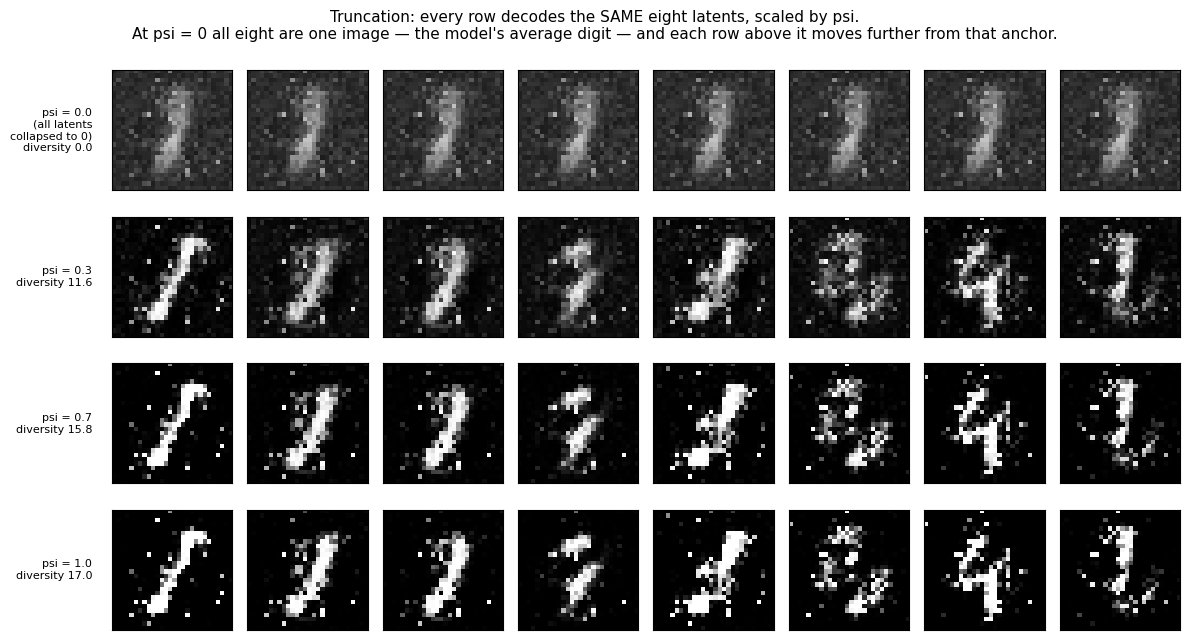


Read the numbers: diversity falls as psi shrinks — the truncation trade-off,
measured on our own GAN. StyleGAN does the same thing in w-space.


In [2]:
# WHAT/WHY: train the simple GAN from example 05, then sample with the
# truncation trick at three psi values — and QUANTIFY the trade-off by
# computing sample diversity (mean pairwise pixel distance) for each psi.
import torchvision, torchvision.transforms as T
import torch.optim as optim

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Same data + architecture as example 05 ────────────────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

# ── Brief adversarial training (see example 05 for the full walkthrough) ──
EPOCHS = 5
for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Truncation trick: sample at psi = 0.3 / 0.7 / 1.0 from the SAME z's ───
G.eval()
# psi = 0 is included as the ANCHOR: it sends every latent to exactly 0, so all
# eight panels of that row are the SAME image — the model's "average digit".
# Without it the rows look nearly identical and the claim is invisible.
psis = [0.0, 0.3, 0.7, 1.0]
base_z = torch.randn(8, LATENT_DIM)      # same base latents for a fair comparison

fig, axes = plt.subplots(len(psis), 8, figsize=(12, 6.6))
print("\npsi   sample diversity (mean pairwise pixel distance)")
for row, psi in enumerate(psis):
    with torch.no_grad():
        imgs = G(psi * base_z).view(-1, 784)       # truncate: pull z toward 0
    # diversity = average L2 distance between all pairs of the 8 samples
    diversity = torch.pdist(imgs).mean().item()
    print(f"{psi:.1f}   {diversity:.2f}")
    for j in range(8):
        axes[row, j].imshow(imgs[j].view(28, 28), cmap='gray', vmin=-1, vmax=1)
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
    label = "psi = 0.0\n(all latents\ncollapsed to 0)" if psi == 0 else f"psi = {psi}"
    axes[row, 0].set_ylabel(f"{label}\ndiversity {diversity:.1f}", fontsize=8,
                            rotation=0, ha="right", va="center", labelpad=14)
plt.suptitle("Truncation: every row decodes the SAME eight latents, scaled by psi.\n"
             "At psi = 0 all eight are one image — the model's average digit — and each row above it "
             "moves further from that anchor.", fontsize=11)
plt.tight_layout(); plt.show()

print("\nRead the numbers: diversity falls as psi shrinks — the truncation trade-off,")
print("measured on our own GAN. StyleGAN does the same thing in w-space.")


**Read the rows against the bottom one.** Every row decodes the *same* eight latent vectors; the only thing that changes is the factor they were multiplied by.

The bottom row, ψ = 0, is the anchor. Scaling by zero sends all eight latents to the same point, so all eight panels are literally the same image — `G(0)`, the one digit this generator draws when it is given no information at all. Its measured diversity is 0.00, and that is what full truncation actually means: one output, forever.

Now read upward. At ψ = 0.3 the eight panels have separated into different shapes, but the whole row is visibly greyer and softer than the two rows below it — the ink is less committed, still pulled toward the anchor. At ψ = 0.7 and ψ = 1.0 the strokes are bright and the columns are eight clearly different attempts at a digit. The diversity number printed beside each row rises with ψ, and the pictures rise with it.

This is the trade the trick makes explicit: **ψ is a dial between "one safe output" and "everything the generator can do, including its failures."** Nothing on this figure says the low-ψ rows are *better* — only that they are more alike, and closer to the average. Whether "closer to the average" means "higher quality" is a judgement about your application, and the note below explains who pays when you decide it does.

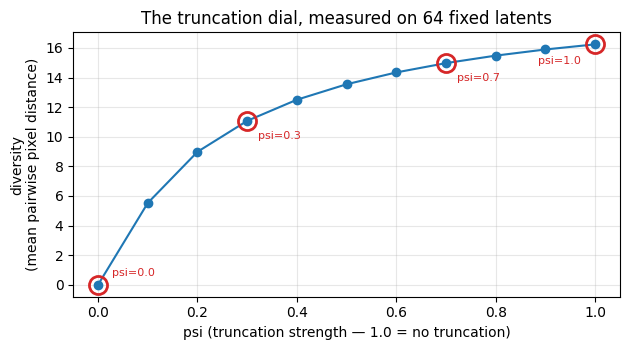

psi    diversity   % of untruncated diversity
0.0      0.00          0%
0.1      5.52         34%
0.2      8.98         55%
0.3     11.08         68%
0.4     12.50         77%
0.5     13.55         83%
0.6     14.35         88%
0.7     14.98         92%
0.8     15.48         95%
0.9     15.90         98%
1.0     16.24        100%


In [3]:
# WHAT/WHY: the grid above sampled three psi values, but truncation is a
# continuous dial. Sweep psi from 0.1 to 1.0 using the SAME 64 latent vectors
# at every setting, measure diversity at each, and plot the trade-off as the
# curve it actually is. No retraining — this is only a change in HOW we sample.
import numpy as np

psi_grid = np.round(np.linspace(0.0, 1.0, 11), 2)   # start at 0: diversity there is exactly 0
sweep_z  = torch.randn(64, LATENT_DIM)      # one fixed pool of latents
diversity = []
with torch.no_grad():
    for p in psi_grid:
        imgs = G(float(p) * sweep_z).view(64, -1)
        diversity.append(torch.pdist(imgs).mean().item())

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(psi_grid, diversity, 'o-')
for p in psis:                              # the settings shown in the grid above
    i = int(np.argmin(np.abs(psi_grid - p)))
    ax.plot(psi_grid[i], diversity[i], 'o', ms=13, mfc='none', mec='tab:red', mew=2)
    # Nudge each label away from the axes edge it is nearest to.
    off = (10, 6) if p <= 0.05 else ((-10, -14) if p >= 0.95 else (8, -13))
    ax.annotate(f"psi={p}", (psi_grid[i], diversity[i]), textcoords="offset points",
                xytext=off, fontsize=8, color='tab:red',
                ha='right' if p >= 0.95 else 'left')
ax.set_xlabel("psi (truncation strength — 1.0 = no truncation)")
ax.set_ylabel("diversity\n(mean pairwise pixel distance)")
ax.set_title("The truncation dial, measured on 64 fixed latents")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("psi    diversity   % of untruncated diversity")
for p, d in zip(psi_grid, diversity):
    print(f"{p:.1f}    {d:6.2f}      {d/diversity[-1]:6.0%}")

**Read the curve, not just the three sampled points.** Diversity falls steadily as ψ shrinks, and the printed percentages say how much of the generator's variety survives each setting: around 90% is still there at ψ = 0.7, but only about a third remains at ψ = 0.1. The circled points mark the four ψ values whose images you can see in the grid above, so you can match a number to a picture — their diversity values differ slightly from the table printed there because this sweep measures 64 latents instead of that grid's 8. Only ψ = 0 agrees exactly, because zero diversity is zero however many samples you measure.

The important part is the *shape*. The dial does not switch quality on at some threshold — every step toward 0 buys typicality by spending variety, continuously, with no free segment anywhere on the axis. That is why a shipped truncation setting is a product decision rather than a tuning detail, and why the "Where this breaks" note below matters: the samples deleted first are the unusual ones.

Two honest caveats. The measurement is pixel distance, so it counts "different pixels", not "different-looking to a person". And the curve only proves what was given up — it says nothing about whether the *remaining* samples got better, which is a judgement the images above have to support.

## 💬 Discuss

1. Our measured diversity fell from **17.03 at ψ = 1.0 to 11.64 at ψ = 0.3**. If you ran a stock-photo service on this generator, which ψ would you ship — and state plainly what the customer no longer gets at that setting.
2. The AP's experts caught the Katie Jones fake by an artefact. Truncation systematically removes the unusual samples where artefacts live. Does truncation make detection harder or easier? Argue from the diversity numbers, not from intuition.
3. Our w-space came from an **untrained** MLP and is already far from Gaussian (z: mean +0.021, std 0.997 → w: mean +0.115, std 0.071). How much of StyleGAN's advantage does that suggest is architecture, and how much is training? What would you run to separate them?


## ⚠️ Where this breaks

**Truncation improves the average sample by deleting the tails — and your minorities live in the tails.** If the application needs rare skin tones, rare defect types, rare dialects or rare poses, ψ < 1 is a diversity cut aimed straight at them. The headline FID may improve while the product gets worse for the people who were already underrepresented.

**Our diversity number is mean pairwise *pixel* distance, not perceptual diversity.** Two images can be far apart in pixels and indistinguishable to a person, or close in pixels and obviously different. Read the number next to the sample grid, never instead of it.

**The mapping network alone does nothing.** We reshaped z → w with untrained weights; the attribute organisation StyleGAN is famous for comes from days of adversarial training on a *narrow, aligned* domain. StyleGAN does not transfer to open-ended scenes — that is what diffusion and text conditioning are for (Unit 3).

**Cheaper alternative:** if you need controllable faces today and do not have GPU-weeks, use a released pretrained checkpoint and edit in its latent space (GANSpace, arXiv 2004.02546) rather than training a StyleGAN of your own.


## 📚 References & Further Reading

**Papers:**
- Karras et al. (2019) — [StyleGAN: A Style-Based Generator Architecture](https://arxiv.org/abs/1812.04948) *(mapping network, style injection, truncation)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)
- Huang & Belongie (2017) — [AdaIN: Arbitrary Style Transfer](https://arxiv.org/abs/1703.06868) *(the normalization behind style injection)*

**Explore:** [thispersondoesnotexist.com](https://thispersondoesnotexist.com) shows StyleGAN output; the official [StyleGAN2 repo](https://github.com/NVlabs/stylegan2) has pretrained models if you have a GPU


## 📝 Summary

In **07 — StyleGAN Basics** you learned the three ideas that make StyleGAN more controllable than a plain GAN — mapping network (z → w), per-layer style injection, truncation — and ran two of them at small scale: you built a mapping network and saw it reshape the latent distribution (histograms above), and you applied the truncation trick to a GAN you trained, measuring how diversity falls as ψ shrinks (printed table). Full-scale StyleGAN training requires days of GPU time — use the pretrained models in the references to explore further.
